# TP7 - Numerical Differentiation

Ce jupyter notebook est la solution commenté du TP7 du cours LBRI1271. Vous trouverez ici plus de détails sur la solution, ainsi que des explications sur l'implélentation de la méthode des différences finies vu au cours et lors du TP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

## Partie 1 : Gradient de pression
Dans la première partie du TP on vous demande calculer le gradient de pression en utilisant la méthode des différences finies. Pour utiliser cette méthode, il faut que les points où on a des données soient équidistants, or ce n'est pas le cas. Il faut donc dans un premier temps interpoler les données fournies à intervalles réguliers.


### 1.1 Interpolation sur une grille régulière
Pour construire une grille de point à intervalles réguliers on utilise la fonction `np.linspace()`. Les deux premiers arguments sont les bornes min et max de l'intervalle et le troisième argument est le nombre de point que l'on souhaite avoir dans l'intervalle considéré. Ici, 500 points sont suffisants. Après avoir construit l'object d'interpolation `cs` avec la fonction `CubicSpline`, il suffit de l'utiliser sur les nouveaux points réguliers.

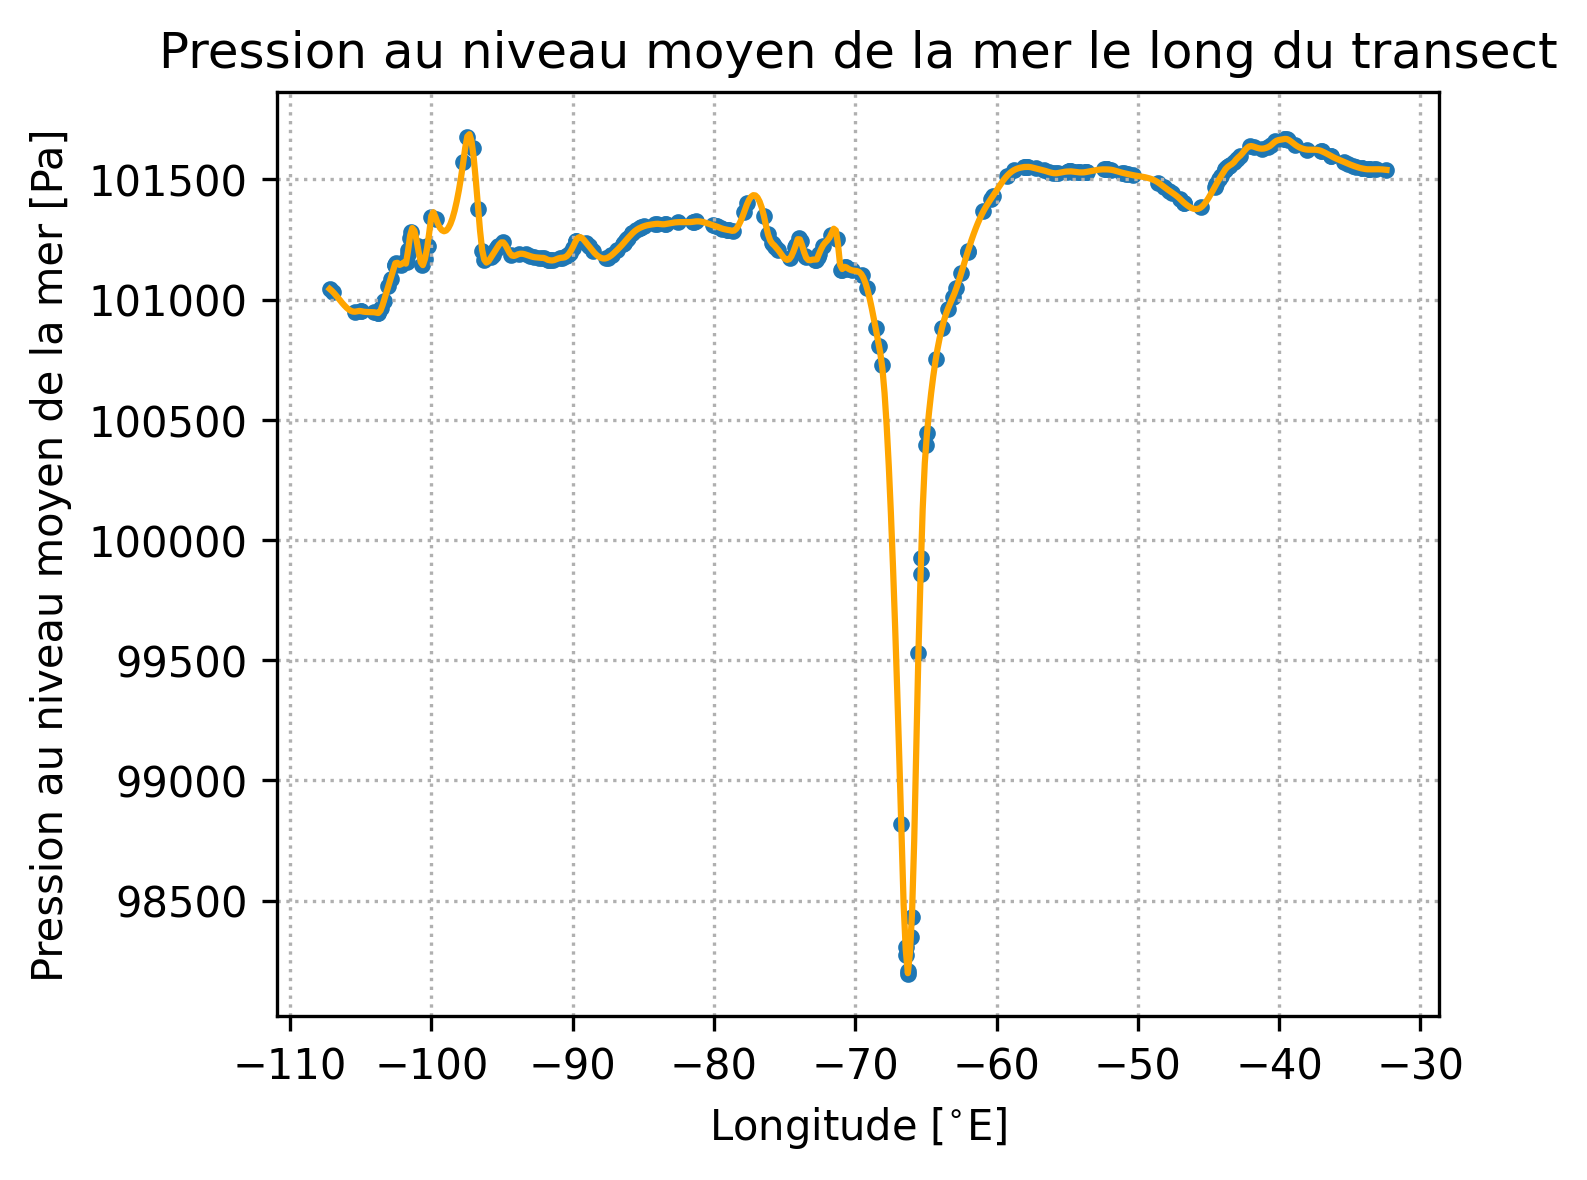

In [6]:
pressure = pd.read_csv('data_TP7/pressure_transect.csv', sep='\t')
lons = pressure['longitude']
mslp = pressure['msl']  # mslp = mean sea level pressure

cs = CubicSpline(lons, mslp)
minlon, maxlon = lons.min(), lons.max()
xs = np.linspace(minlon, maxlon, 500)
p_interp = cs(xs)

plt.figure(dpi=300, figsize=(5,4))
plt.title('Pression au niveau moyen de la mer le long du transect')
plt.plot(xs, p_interp, c='orange')
plt.scatter(lons, mslp, marker='.')
plt.grid(linestyle=':')
plt.xlabel(r'Longitude [$^{\circ}$E]')
plt.ylabel('Pression au niveau moyen de la mer [Pa]')
plt.show()

### 1.2 Calcul du gradient de pression

On vous demande de calculer le gradient de pression $\partial{p} / \partial{x}$ en utilisant la méthode des différences finies centrées. La principe de cette méthode est d'approximer la dérivée par un taux de variation discret entre points voisins : pour la valeur de pression donnée $p(x_i)$ pour laquelle il existe une valeure de pression en $i-1$ et $i+1$, l'expression discrète est de la forme:
$$
   \frac{\partial{p(x)}}{\partial{x}}  \approx \frac{p(x_{i+1}) - p(x_{i-1})}{2 \Delta x}
$$
où $\Delta x$ est la distance (en mètres) entre deux points. Pour les points sur les frontières, c'est-à-dire le premier ($i=1$) et dernier point de la grille ($i=n$), on utilisera uniquement la valeur voisine existante selon le cas.

On peut implémenter ça de deux façons différentes : soit avec une boucle (qui est la solution la plus intuitive), soit en faisant des slices; une opérations qui est très efficace quand on travaille avec des NumPy arrays. 
Dans les deux cas on commence par allouer un arrays de la même taille que `xs`. Comme on veut une valeure du gradient pour chaque point de pression, on connait déjà la taille de notre array de gradient de pression qui est `len(xs)`. 

Pour la première approche avec la boucle, on souhaite visiter uniquement les valeurs de pression qui ont des voisins à gauche et à droite. Cela correspond à considérer de valeur de $i$ allant de 1 à len(xs)-1 (n'oubliez pas qu'en Python on compte à partir de 0!). On traite ensuite manuellement les cas aux frontières. Notez aussi que la valeur de la borne max de la function `range` est exclue. Donc si $\text{len(xs)}-1=499$, la dernière valeure de $i$ sera $498$, qui est bien l'index de l'avant-dernier élement de `dpdx`. 

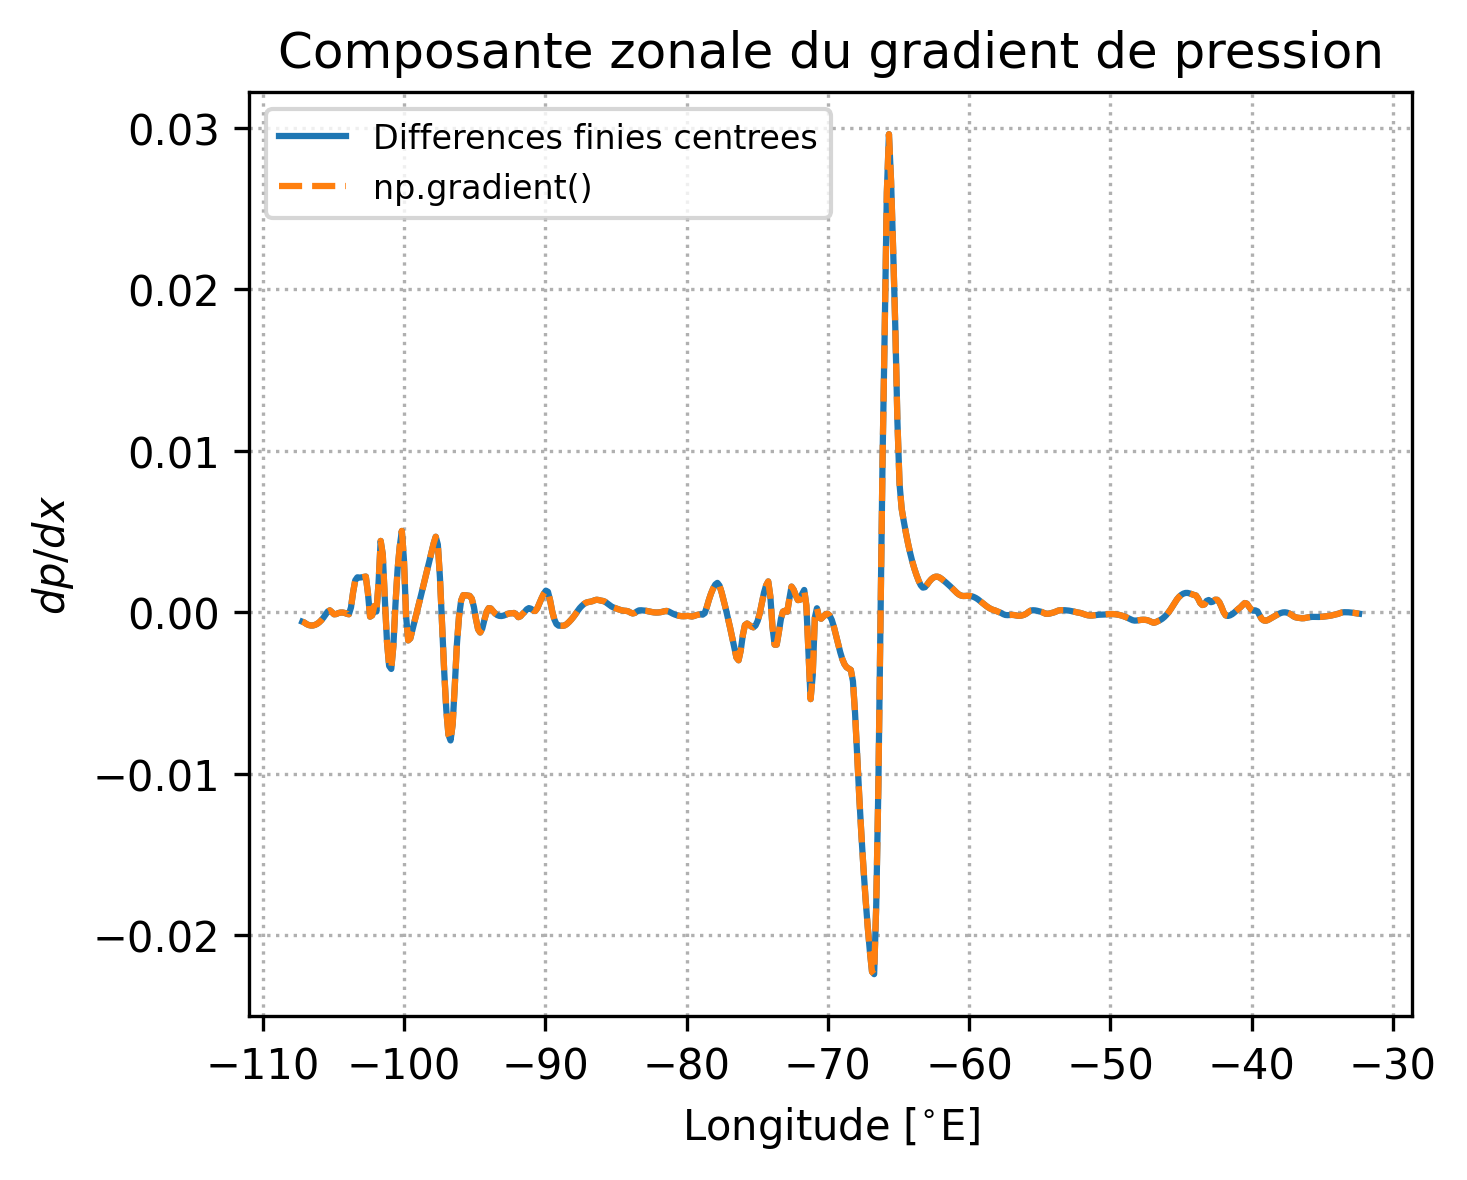

In [ ]:
dx = 6371e3 * np.cos(18.2) * np.deg2rad(xs[1]-xs[0]) # conversion degrés -> mètres

dpdx = np.zeros(len(xs))
for i in range(1, len(xs)-1):
    dpdx[i] = (p_interp[i+1] - p_interp[i-1])/(2*dx)
dpdx[0]  = (p_interp[1] - p_interp[0])/dx
dpdx[-1] = (p_interp[-1] - p_interp[-2])/dx

dpdx_grad = np.gradient(p_interp, dx)

plt.figure(dpi=300, figsize=(5,4))
plt.title('Composante zonale du gradient de pression')
plt.plot(xs, dpdx, label='Differences finies centrees')
plt.plot(xs, dpdx_grad, '--', label='np.gradient()')
plt.grid(linestyle=':')
plt.xlabel(r'Longitude [$^{\circ}$E]')
plt.ylabel(r'$dp/dx$')
plt.legend(fontsize=8)
plt.show()

Avec les slices de NumPy, l'approche pour les valeurs aux frontières est la même. Ce qui change c'est l'approche pour les valeurs internes. Au lieu de boucler et d'aller chercher les voisins pour le ième élément, on va directement aller chercher tous les voisins de droites et tous les éléments de gauche. La première valeur interne (cad a un voisin à gauche et à droite) se situe à l'index 1, donc le premier voisin de droite se trouve à l'index 2. Donc tous les voisins de droites sont toutes les valeurs qui se trouvent après l'index 2 inclus : `p_interp[2:]`. A l'inverse, tous les voisins de gauches se trouvent à partir de l'index $0$ jusque l'avant-avant-dernier élément : `p_interp[:-2]`.